# The Black-Scholes Model: Pricing Options with Mathematics

> *"The most celebrated formula in all of finance."*

This notebook walks through the Black-Scholes model from first principles — what options are, how stock prices are modeled, how the famous formula is derived, and what the Greeks tell us. We use math, intuition, and Python visualizations throughout.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import norm
import ipywidgets as widgets
from ipywidgets import interact

plt.rcParams.update({
    "figure.facecolor":  "white",
    "axes.facecolor":    "#f8f8f8",
    "axes.grid":         True,
    "grid.color":        "white",
    "grid.linewidth":    1.2,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "font.family":       "sans-serif",
})

## 1 · What Is an Option?

---

Imagine you're interested in buying a stock currently trading at **\$100**, but you're not sure whether the price will go up or down. You'd like the *right* to buy it at \$100 later — without being *obligated* to do so. That's exactly what a **call option** is.

### The two fundamental option types

| Option Type | Right it gives you | You profit when... |
|-------------|-------------------|-------------------|
| **Call** | Buy the stock at price $K$ | Stock price **rises** above $K$ |
| **Put** | Sell the stock at price $K$ | Stock price **falls** below $K$ |

### Key terminology

| Symbol | Name | Intuition |
|--------|------|-----------|
| $S$ | Current stock price | Where the stock trades *right now* |
| $K$ | Strike price | The price locked in by the option contract |
| $T$ | Time to expiry (years) | How long the option is valid |
| $r$ | Risk-free rate | What you'd earn in a savings account (e.g. 5%) |
| $\sigma$ | Volatility | How wildly the stock price swings (annualized) |
| $C$ | Call option price | What you *pay* for the right to buy |
| $P$ | Put option price | What you *pay* for the right to sell |

### Payoff at expiry

At expiration, the option is worth:

$$\text{Call payoff} = \max(S_T - K,\ 0)$$
$$\text{Put payoff} = \max(K - S_T,\ 0)$$

Think of $\max(\cdot, 0)$ as a safety net — if the option would cost you money, you simply don't exercise it. You lose only the premium you paid upfront.

> **Key insight:** An option has *asymmetric* payoff — unlimited upside, capped downside (the premium). This asymmetry is exactly what makes it valuable and mathematically interesting to price.

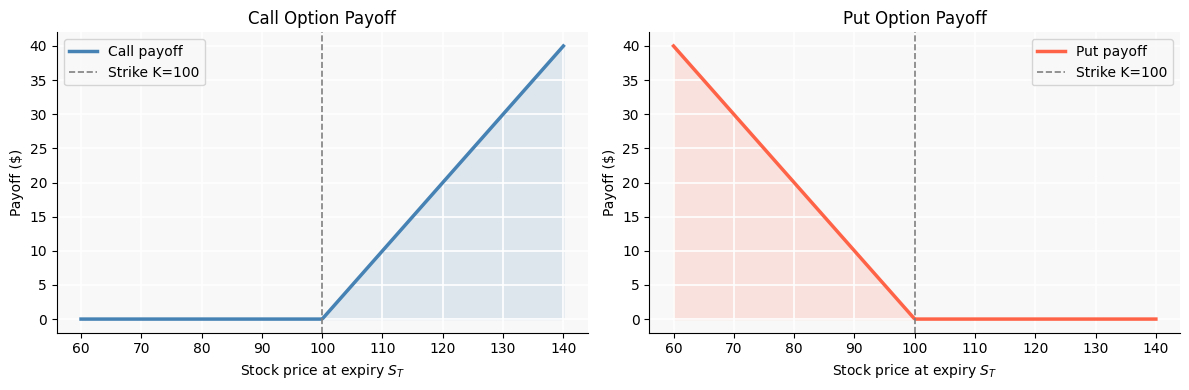

In [2]:
S_T = np.linspace(60, 140, 400)
K = 100

call_payoff = np.maximum(S_T - K, 0)
put_payoff  = np.maximum(K - S_T, 0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(S_T, call_payoff, color="steelblue", lw=2.5, label="Call payoff")
axes[0].axvline(K, color="gray", ls="--", lw=1.2, label=f"Strike K={K}")
axes[0].fill_between(S_T, call_payoff, alpha=0.15, color="steelblue")
axes[0].set_xlabel("Stock price at expiry $S_T$")
axes[0].set_ylabel("Payoff ($)")
axes[0].set_title("Call Option Payoff")
axes[0].legend()

axes[1].plot(S_T, put_payoff, color="tomato", lw=2.5, label="Put payoff")
axes[1].axvline(K, color="gray", ls="--", lw=1.2, label=f"Strike K={K}")
axes[1].fill_between(S_T, put_payoff, alpha=0.15, color="tomato")
axes[1].set_xlabel("Stock price at expiry $S_T$")
axes[1].set_ylabel("Payoff ($)")
axes[1].set_title("Put Option Payoff")
axes[1].legend()

plt.tight_layout()
plt.show()

## 2 · How Do Stock Prices Move? Geometric Brownian Motion

---

Before pricing an option, we need a model for *how the stock price evolves over time*. Black, Scholes, and Merton's key assumption is:

### Stock prices follow Geometric Brownian Motion (GBM)

$$dS = \mu S \, dt + \sigma S \, dW_t$$

Let's unpack each term like it's a recipe:

| Term | Meaning | Analogy |
|------|---------|---------|
| $dS$ | Tiny change in stock price | A small step |
| $\mu S \, dt$ | **Drift** — the average upward trend | Like walking uphill at a steady pace |
| $\sigma S \, dW_t$ | **Diffusion** — random noise | Like the wind randomly pushing you left or right |
| $\sigma$ | Volatility — how noisy the stock is | How strong the wind is |
| $dW_t$ | Wiener process increment ~ $\mathcal{N}(0, dt)$ | A random coin flip, scaled |

> **Key insight:** The $S$ multiplying both terms means *returns* are random, not price *levels*. A \$1 swing matters more for a \$10 stock than a \$1000 stock.

### The solution: Log-normal prices

Applying Itô's lemma (calculus for random processes) to solve the SDE above:

$$S_T = S_0 \exp\!\left[\left(\mu - \frac{\sigma^2}{2}\right)T + \sigma\sqrt{T}\, Z\right], \quad Z \sim \mathcal{N}(0, 1)$$

The $-\sigma^2/2$ correction is subtle but important — it's a **Jensen's inequality** adjustment. Because $e^x$ is convex, the average of $e^x$ is *larger* than $e^{\text{average of } x}$, so we subtract $\sigma^2/2$ to keep the expected return honest.

Taking the log: $\ln(S_T/S_0) \sim \mathcal{N}\!\left((\mu - \sigma^2/2)T,\ \sigma^2 T\right)$

This is why we call it **log-normal**: the *log* of price is normally distributed.

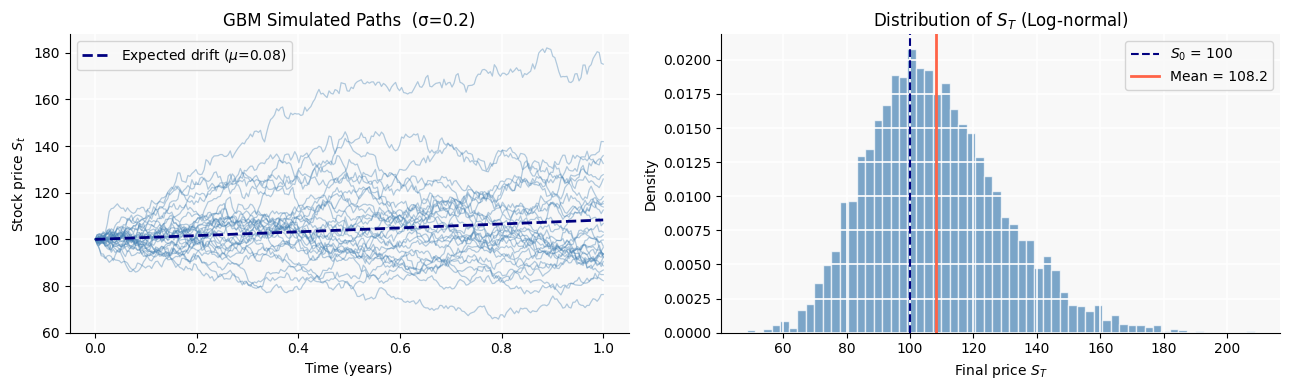

Theoretical mean S_T: 108.33
Simulated  mean S_T: 108.18


In [3]:
np.random.seed(42)

S0    = 100
mu    = 0.08
sigma = 0.2
T     = 1.0
N     = 252
dt    = T / N
n_paths = 30

t = np.linspace(0, T, N + 1)
paths = np.zeros((n_paths, N + 1))
paths[:, 0] = S0

for i in range(1, N + 1):
    Z = np.random.standard_normal(n_paths)
    paths[:, i] = paths[:, i-1] * np.exp((mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for path in paths:
    axes[0].plot(t, path, alpha=0.4, lw=0.9, color="steelblue")
axes[0].plot(t, S0 * np.exp(mu * t), color="navy", lw=2, ls="--", label=f"Expected drift ($\\mu$={mu})")
axes[0].set_xlabel("Time (years)")
axes[0].set_ylabel("Stock price $S_t$")
axes[0].set_title(f"GBM Simulated Paths  (σ={sigma})")
axes[0].legend()

final_prices = paths[:, -1]
n_sim = 5000
Z_final = np.random.standard_normal(n_sim)
S_final = S0 * np.exp((mu - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z_final)

axes[1].hist(S_final, bins=60, color="steelblue", alpha=0.7, edgecolor="white", density=True)
axes[1].axvline(S0, color="navy", ls="--", lw=1.5, label=f"$S_0$ = {S0}")
axes[1].axvline(np.mean(S_final), color="tomato", ls="-", lw=2, label=f"Mean = {np.mean(S_final):.1f}")
axes[1].set_xlabel("Final price $S_T$")
axes[1].set_ylabel("Density")
axes[1].set_title("Distribution of $S_T$ (Log-normal)")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Theoretical mean S_T: {S0 * np.exp(mu * T):.2f}")
print(f"Simulated  mean S_T: {np.mean(S_final):.2f}")

## 3 · The Black-Scholes Formula

---

### From PDE to closed form

Black and Scholes asked: *can we build a portfolio of stocks and options that has no risk?* If yes, that portfolio must earn the risk-free rate $r$ (otherwise there's an arbitrage). This "delta-hedging" argument leads to the **Black-Scholes PDE**:

$$\frac{\partial V}{\partial t} + \frac{1}{2}\sigma^2 S^2 \frac{\partial^2 V}{\partial S^2} + rS\frac{\partial V}{\partial S} - rV = 0$$

where $V(S, t)$ is the option price. This is a partial differential equation (PDE) — it links how the price changes in time and space.

Solving this PDE with the boundary condition $V(S_T, T) = \max(S_T - K, 0)$ (call payoff at expiry) gives the famous closed-form formula.

---

### The Black-Scholes formula for a European call

$$\boxed{C = S \cdot N(d_1) - K e^{-rT} \cdot N(d_2)}$$

where:

$$d_1 = \frac{\ln(S/K) + \left(r + \dfrac{\sigma^2}{2}\right)T}{\sigma\sqrt{T}}, \qquad d_2 = d_1 - \sigma\sqrt{T}$$

and $N(\cdot)$ is the **standard normal CDF** (the area under the bell curve up to that point).

### Intuition for each piece

| Piece | What it means |
|-------|--------------|
| $N(d_2)$ | Probability the option ends **in the money** (under the risk-neutral measure) — i.e., $S_T > K$ |
| $K e^{-rT}$ | Present value of the strike price (discounted at risk-free rate) |
| $K e^{-rT} N(d_2)$ | Expected cost of buying the stock at strike, discounted |
| $N(d_1)$ | A "probability-weighted" factor accounting for the stock price's upside |
| $S \cdot N(d_1)$ | Expected value of receiving the stock, conditional on exercising |

> **Key insight:** The formula is essentially **"what you expect to get" minus "what you expect to pay"**, both probability-weighted and time-discounted. It's the expected payoff of the option under the *risk-neutral* world.

### The "risk-neutral" trick (why $\mu$ disappears!)

Notice: $\mu$ (the actual drift) does **not** appear in the formula — only $r$ (the risk-free rate) does. This is the magic of risk-neutral pricing: we replace the real-world drift with $r$, price in that imaginary world, and it turns out the result is the same arbitrage-free price regardless of what $\mu$ actually is.

### European put via put-call parity

Rather than re-solving the PDE, we use **put-call parity**:

$$C - P = S - K e^{-rT}$$

So:

$$P = K e^{-rT} N(-d_2) - S \cdot N(-d_1)$$

In [4]:
def black_scholes(S, K, T, r, sigma, option="call"):
    """Black-Scholes formula for European call or put."""
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    if option == "call":
        return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    else:
        return K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)

# Example pricing
S, K, T, r, sigma = 100, 100, 1.0, 0.05, 0.2
call_price = black_scholes(S, K, T, r, sigma, "call")
put_price  = black_scholes(S, K, T, r, sigma, "put")

print(f"Parameters: S={S}, K={K}, T={T}yr, r={r:.0%}, σ={sigma:.0%}")
print(f"Call price: ${call_price:.4f}")
print(f"Put  price: ${put_price:.4f}")
print(f"Put-call parity check: C - P = {call_price - put_price:.4f},  S - Ke^(-rT) = {S - K*np.exp(-r*T):.4f}")

Parameters: S=100, K=100, T=1.0yr, r=5%, σ=20%
Call price: $10.4506
Put  price: $5.5735
Put-call parity check: C - P = 4.8771,  S - Ke^(-rT) = 4.8771


## 4 · Visualizing Option Prices

---

The Black-Scholes price is always **higher than the intrinsic payoff** before expiry — the difference is the **time value**: the extra amount you pay for the chance that the option can still go further in the money.

Let's visualize how option prices behave as we vary the stock price and time to expiry.

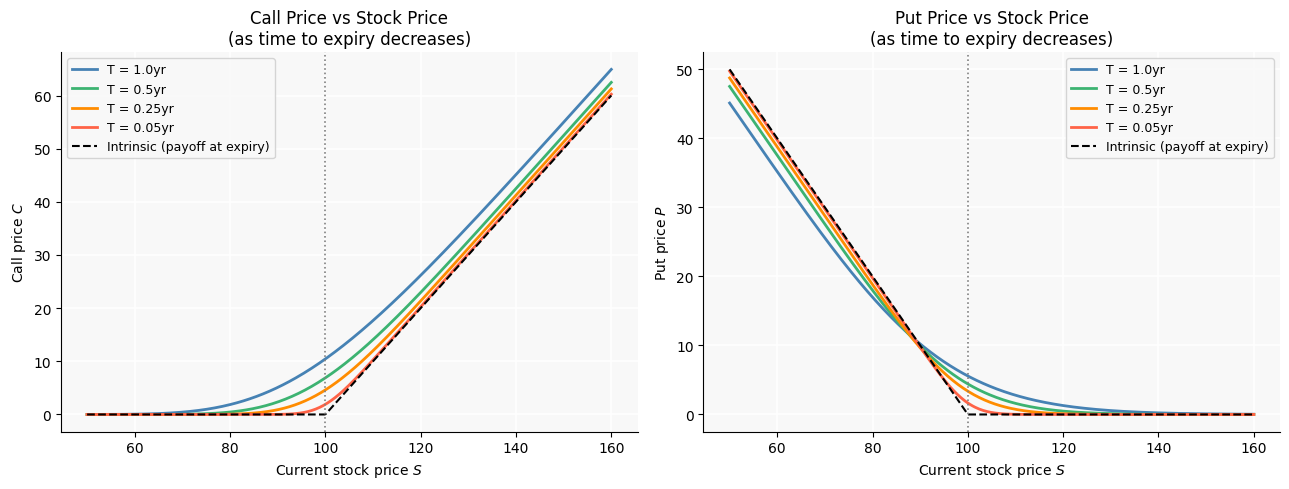

In [5]:
K, r, sigma = 100, 0.05, 0.2
S_range = np.linspace(50, 160, 400)
T_values = [1.0, 0.5, 0.25, 0.05]
colors   = ["steelblue", "mediumseagreen", "darkorange", "tomato"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

intrinsic_call = np.maximum(S_range - K, 0)
intrinsic_put  = np.maximum(K - S_range, 0)

for T_val, col in zip(T_values, colors):
    call_prices = [black_scholes(s, K, T_val, r, sigma, "call") for s in S_range]
    put_prices  = [black_scholes(s, K, T_val, r, sigma, "put")  for s in S_range]
    axes[0].plot(S_range, call_prices, color=col, lw=2, label=f"T = {T_val}yr")
    axes[1].plot(S_range, put_prices,  color=col, lw=2, label=f"T = {T_val}yr")

axes[0].plot(S_range, intrinsic_call, "k--", lw=1.5, label="Intrinsic (payoff at expiry)")
axes[0].axvline(K, color="gray", ls=":", lw=1.2)
axes[0].set_xlabel("Current stock price $S$")
axes[0].set_ylabel("Call price $C$")
axes[0].set_title("Call Price vs Stock Price\n(as time to expiry decreases)")
axes[0].legend(fontsize=9)

axes[1].plot(S_range, intrinsic_put, "k--", lw=1.5, label="Intrinsic (payoff at expiry)")
axes[1].axvline(K, color="gray", ls=":", lw=1.2)
axes[1].set_xlabel("Current stock price $S$")
axes[1].set_ylabel("Put price $P$")
axes[1].set_title("Put Price vs Stock Price\n(as time to expiry decreases)")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

## 5 · The Greeks — Sensitivities of Option Price

---

The **Greeks** measure how the option price changes when each input changes slightly. They're used by traders to manage risk.

| Greek | Symbol | Measures sensitivity to... | Intuition |
|-------|--------|---------------------------|-----------|
| Delta | $\Delta$ | Stock price $S$ | How much the option moves per \$1 move in the stock |
| Gamma | $\Gamma$ | Rate of change of Delta | How "curvy" the option price is — the acceleration |
| Theta | $\Theta$ | Time passing | Daily loss in value (time decay) |
| Vega | $\mathcal{V}$ | Volatility $\sigma$ | Gain/loss per 1% increase in volatility |
| Rho | $\rho$ | Interest rate $r$ | Gain/loss per 1% increase in rates |

### Analytical formulas

$$\Delta_{\text{call}} = N(d_1), \qquad \Delta_{\text{put}} = N(d_1) - 1$$

$$\Gamma = \frac{N'(d_1)}{S \sigma \sqrt{T}}, \quad \text{where } N'(x) = \frac{1}{\sqrt{2\pi}}e^{-x^2/2}$$

$$\Theta_{\text{call}} = -\frac{S \sigma N'(d_1)}{2\sqrt{T}} - r K e^{-rT} N(d_2)$$

$$\mathcal{V} = S \sqrt{T} \, N'(d_1)$$

> **Key insight:** Delta tells you how to **hedge** — if you buy one call (Delta ≈ 0.5), you need to short 0.5 shares to be market-neutral. This is the hedge that Black and Scholes maintained to derive their formula.

/var/folders/3w/nf3t5ncs1w7cnxw9_g7ckl2h0000gn/T/ipykernel_14050/2778001276.py:52: UserWarning: Glyph 119985 (\N{MATHEMATICAL SCRIPT CAPITAL V}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/wanchuan/ml-learn/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 119985 (\N{MATHEMATICAL SCRIPT CAPITAL V}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


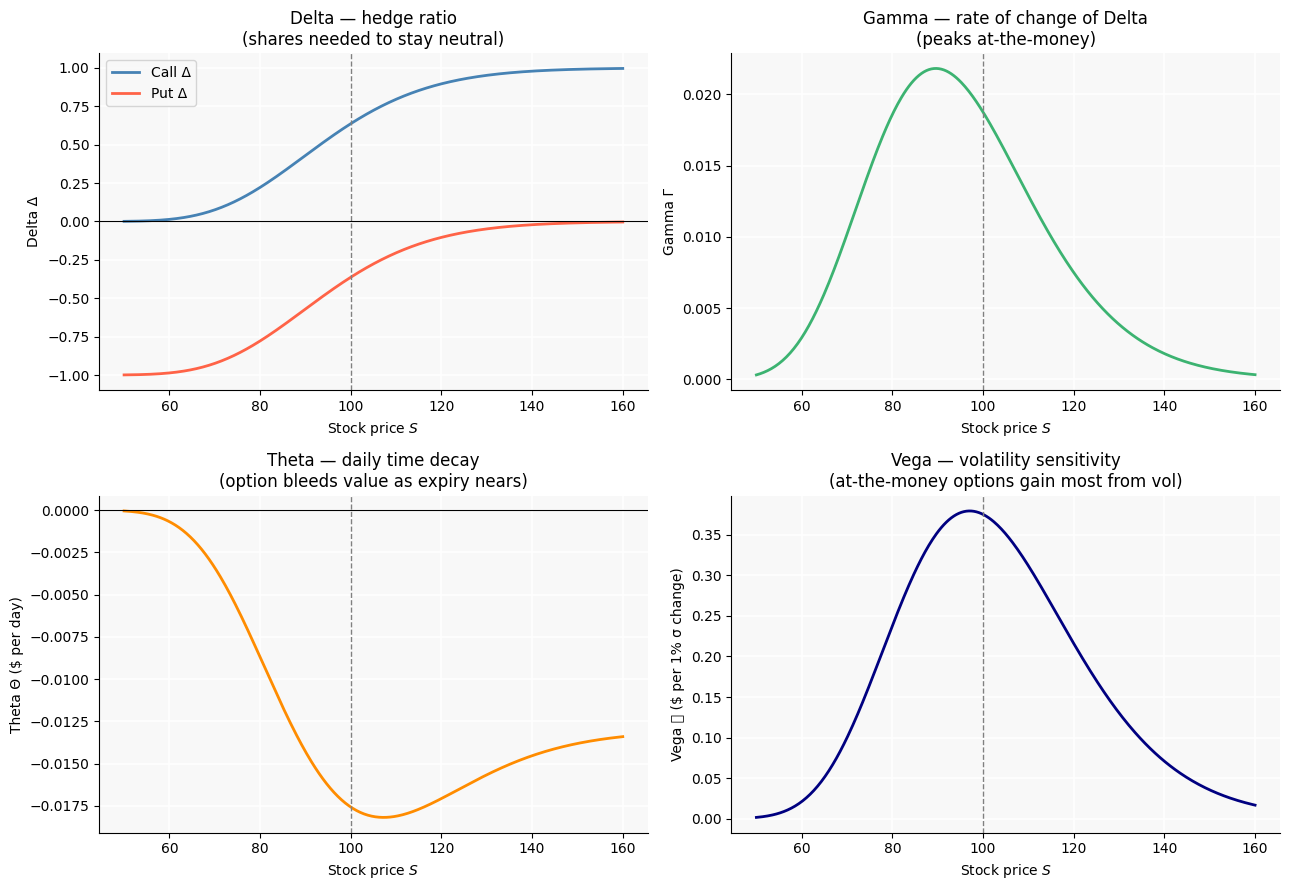

In [6]:
def greeks(S, K, T, r, sigma):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    nprime_d1 = norm.pdf(d1)

    delta_call = norm.cdf(d1)
    delta_put  = norm.cdf(d1) - 1
    gamma      = nprime_d1 / (S * sigma * np.sqrt(T))
    theta_call = (-S * sigma * nprime_d1 / (2 * np.sqrt(T)) - r * K * np.exp(-r * T) * norm.cdf(d2)) / 365
    vega       = S * np.sqrt(T) * nprime_d1 / 100  # per 1% change in sigma
    rho_call   = K * T * np.exp(-r * T) * norm.cdf(d2) / 100

    return delta_call, delta_put, gamma, theta_call, vega, rho_call

S_range = np.linspace(50, 160, 400)
K, T, r, sigma = 100, 1.0, 0.05, 0.2

deltas_call, deltas_put, gammas, thetas, vegas, rhos = zip(
    *[greeks(s, K, T, r, sigma) for s in S_range]
)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

axes[0,0].plot(S_range, deltas_call, color="steelblue", lw=2, label="Call Δ")
axes[0,0].plot(S_range, deltas_put,  color="tomato",    lw=2, label="Put Δ")
axes[0,0].axvline(K, color="gray", ls="--", lw=1)
axes[0,0].axhline(0, color="black", lw=0.8)
axes[0,0].set_xlabel("Stock price $S$")
axes[0,0].set_ylabel("Delta Δ")
axes[0,0].set_title("Delta — hedge ratio\n(shares needed to stay neutral)")
axes[0,0].legend()

axes[0,1].plot(S_range, gammas, color="mediumseagreen", lw=2)
axes[0,1].axvline(K, color="gray", ls="--", lw=1)
axes[0,1].set_xlabel("Stock price $S$")
axes[0,1].set_ylabel("Gamma Γ")
axes[0,1].set_title("Gamma — rate of change of Delta\n(peaks at-the-money)")

axes[1,0].plot(S_range, thetas, color="darkorange", lw=2)
axes[1,0].axvline(K, color="gray", ls="--", lw=1)
axes[1,0].axhline(0, color="black", lw=0.8)
axes[1,0].set_xlabel("Stock price $S$")
axes[1,0].set_ylabel("Theta Θ ($ per day)")
axes[1,0].set_title("Theta — daily time decay\n(option bleeds value as expiry nears)")

axes[1,1].plot(S_range, vegas, color="navy", lw=2)
axes[1,1].axvline(K, color="gray", ls="--", lw=1)
axes[1,1].set_xlabel("Stock price $S$")
axes[1,1].set_ylabel("Vega 𝒱 ($ per 1% σ change)")
axes[1,1].set_title("Vega — volatility sensitivity\n(at-the-money options gain most from vol)")

plt.tight_layout()
plt.show()

## 6 · Monte Carlo Verification

---

We can verify the Black-Scholes formula with brute-force simulation: simulate thousands of future stock prices, compute the option payoff for each, average them, and discount back to today. If BS is correct, they should match.

This is also a great sanity check — and the only way to price more exotic options that have no closed form.

                           Call        Put
Black-Scholes           10.4506     5.5735
Monte Carlo             10.4324     5.5353
Difference               0.0182     0.0382


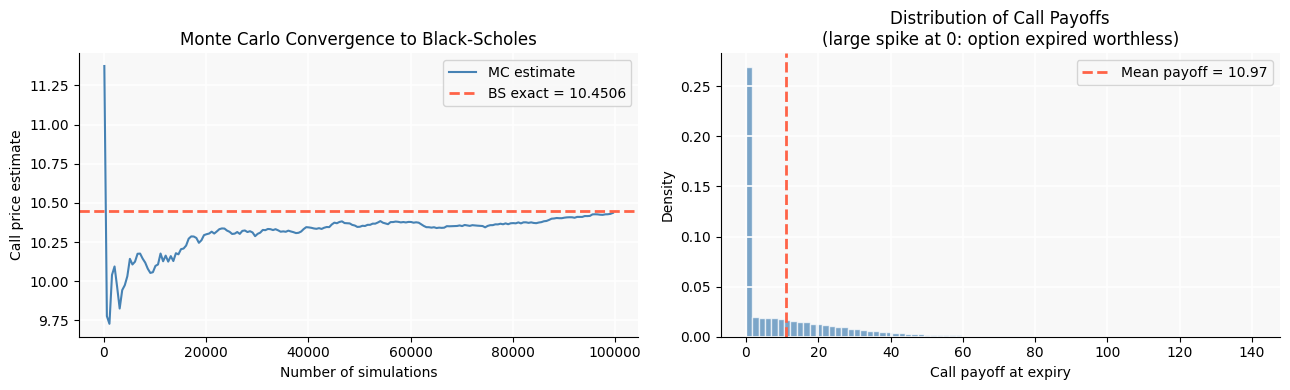

In [7]:
np.random.seed(0)
S0, K, T, r, sigma = 100, 100, 1.0, 0.05, 0.2
n_sims = 100_000

Z = np.random.standard_normal(n_sims)
S_T = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)

call_payoffs = np.maximum(S_T - K, 0)
put_payoffs  = np.maximum(K - S_T, 0)

mc_call = np.exp(-r * T) * np.mean(call_payoffs)
mc_put  = np.exp(-r * T) * np.mean(put_payoffs)
bs_call = black_scholes(S0, K, T, r, sigma, "call")
bs_put  = black_scholes(S0, K, T, r, sigma, "put")

print(f"{'':20} {'Call':>10} {'Put':>10}")
print(f"{'Black-Scholes':20} {bs_call:>10.4f} {bs_put:>10.4f}")
print(f"{'Monte Carlo':20} {mc_call:>10.4f} {mc_put:>10.4f}")
print(f"{'Difference':20} {abs(bs_call-mc_call):>10.4f} {abs(bs_put-mc_put):>10.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

n_steps = np.arange(100, 100_001, 500)
running_call = np.cumsum(call_payoffs[:len(n_steps)*500:500]) / np.arange(1, len(n_steps)+1)
running_call_full = np.array([np.exp(-r*T) * np.mean(call_payoffs[:n]) for n in n_steps])

axes[0].plot(n_steps, running_call_full, color="steelblue", lw=1.5, label="MC estimate")
axes[0].axhline(bs_call, color="tomato", lw=2, ls="--", label=f"BS exact = {bs_call:.4f}")
axes[0].set_xlabel("Number of simulations")
axes[0].set_ylabel("Call price estimate")
axes[0].set_title("Monte Carlo Convergence to Black-Scholes")
axes[0].legend()

axes[1].hist(call_payoffs, bins=80, color="steelblue", alpha=0.7, edgecolor="white", density=True)
axes[1].axvline(np.mean(call_payoffs), color="tomato", lw=2, ls="--", label=f"Mean payoff = {np.mean(call_payoffs):.2f}")
axes[1].set_xlabel("Call payoff at expiry")
axes[1].set_ylabel("Density")
axes[1].set_title("Distribution of Call Payoffs\n(large spike at 0: option expired worthless)")
axes[1].legend()

plt.tight_layout()
plt.show()

## 7 · Interactive Explorer

---

Use the sliders below to see how each parameter changes the call/put price and the Greeks in real time.

- **S** — push the stock price above or below the strike
- **σ** — crank volatility up; watch the option get more expensive
- **T** — reduce time to expiry; watch the option lose time value (theta decay)

In [ ]:
def plot_bs_interactive(S=100, K=100, T=1.0, r=0.05, sigma=0.2):
    S_range = np.linspace(50, 160, 400)

    call_prices = [black_scholes(s, K, T, r, sigma, "call") for s in S_range]
    put_prices  = [black_scholes(s, K, T, r, sigma, "put")  for s in S_range]
    deltas_c    = [norm.cdf((np.log(s/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))) for s in S_range]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].plot(S_range, call_prices, color="steelblue", lw=2, label="Call")
    axes[0].plot(S_range, put_prices,  color="tomato",    lw=2, label="Put")
    axes[0].axvline(S, color="navy", ls="--", lw=1.5, label=f"Current S={S}")
    axes[0].axvline(K, color="gray", ls=":",  lw=1.2, label=f"Strike K={K}")
    c_now = black_scholes(S, K, T, r, sigma, "call")
    p_now = black_scholes(S, K, T, r, sigma, "put")
    axes[0].scatter([S], [c_now], color="steelblue", s=80, zorder=5)
    axes[0].scatter([S], [p_now], color="tomato",    s=80, zorder=5)
    axes[0].set_xlabel("Stock price $S$"); axes[0].set_ylabel("Option price")
    axes[0].set_title(f"Call=${c_now:.2f}  Put=${p_now:.2f}")
    axes[0].legend(fontsize=8)

    axes[1].plot(S_range, deltas_c, color="mediumseagreen", lw=2, label="Call Δ")
    axes[1].plot(S_range, [d-1 for d in deltas_c], color="darkorange", lw=2, label="Put Δ")
    d_now = norm.cdf((np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T)))
    axes[1].axvline(S, color="navy", ls="--", lw=1.5)
    axes[1].axhline(0, color="black", lw=0.8)
    axes[1].scatter([S], [d_now], color="mediumseagreen", s=80, zorder=5)
    axes[1].set_xlabel("Stock price $S$"); axes[1].set_ylabel("Delta")
    axes[1].set_title(f"Delta = {d_now:.3f}")
    axes[1].legend(fontsize=8)

    sigmas = np.linspace(0.05, 0.8, 200)
    calls_vs_vol = [black_scholes(S, K, T, r, s, "call") for s in sigmas]
    axes[2].plot(sigmas, calls_vs_vol, color="navy", lw=2)
    axes[2].axvline(sigma, color="tomato", ls="--", lw=1.5, label=f"σ={sigma:.2f}")
    axes[2].scatter([sigma], [black_scholes(S, K, T, r, sigma, "call")], color="tomato", s=80, zorder=5)
    axes[2].set_xlabel("Volatility σ"); axes[2].set_ylabel("Call price")
    axes[2].set_title("Call price vs Volatility")
    axes[2].legend(fontsize=8)

    plt.tight_layout()
    plt.show()

interact(
    plot_bs_interactive,
    S=widgets.FloatSlider(value=100, min=50,  max=160,  step=1,    description="S (stock)"),
    K=widgets.FloatSlider(value=100, min=50,  max=150,  step=1,    description="K (strike)"),
    T=widgets.FloatSlider(value=1.0, min=0.1, max=3.0,  step=0.1,  description="T (years)"),
    r=widgets.FloatSlider(value=0.05,min=0.0, max=0.15, step=0.01, description="r (rate)"),
    sigma=widgets.FloatSlider(value=0.2, min=0.05, max=0.8, step=0.01, description="σ (vol)"),
);

interactive(children=(FloatSlider(value=100.0, description='S (stock)', max=160.0, min=50.0, step=1.0), FloatS…

## 8 · Assumptions and Limitations

---

Black-Scholes is elegant but rests on several assumptions that don't always hold in the real world:

| Assumption | Reality |
|-----------|---------|
| Constant volatility $\sigma$ | Volatility *smiles* — it varies by strike and expiry |
| Continuous trading, no transaction costs | Markets have bid-ask spreads and close overnight |
| Log-normal returns | Real returns have **fat tails** (crashes are more common than the model predicts) |
| European-style exercise only | American options can be exercised early — no closed-form solution |
| No dividends | Easily extended (add dividend yield $q$: replace $S$ with $Se^{-qT}$) |
| Risk-free rate is constant | Rates change over time |

### The volatility smile
In real markets, implied volatility (the $\sigma$ that makes BS price match market price) is **not flat** — it's a smile or skew across strikes. This is the market's way of pricing in fat tails that BS doesn't account for.

> **Key insight:** Despite its imperfections, Black-Scholes remains the industry *lingua franca* for quoting options. Traders don't use it naively — they use **implied volatility** as a unit of price, then build corrections on top.

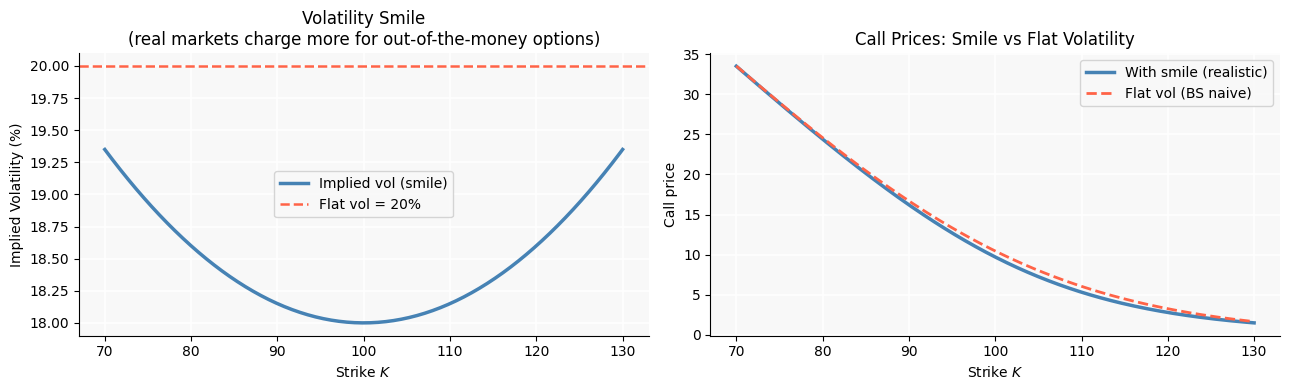

In [9]:
strikes = np.linspace(70, 130, 200)
S0, T, r = 100, 1.0, 0.05

# Simulated volatility smile: lower vol for near-ATM, higher for wings
smile_vol = 0.18 + 0.15 * ((strikes - 100) / 100) ** 2
flat_vol   = np.full_like(strikes, 0.20)

call_smile = [black_scholes(S0, k, T, r, v, "call") for k, v in zip(strikes, smile_vol)]
call_flat  = [black_scholes(S0, k, T, r, 0.20, "call") for k in strikes]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(strikes, smile_vol * 100, color="steelblue", lw=2.5, label="Implied vol (smile)")
axes[0].axhline(20, color="tomato", ls="--", lw=1.8, label="Flat vol = 20%")
axes[0].set_xlabel("Strike $K$")
axes[0].set_ylabel("Implied Volatility (%)")
axes[0].set_title("Volatility Smile\n(real markets charge more for out-of-the-money options)")
axes[0].legend()

axes[1].plot(strikes, call_smile, color="steelblue", lw=2.5, label="With smile (realistic)")
axes[1].plot(strikes, call_flat,  color="tomato",    lw=2,   ls="--", label="Flat vol (BS naive)")
axes[1].set_xlabel("Strike $K$")
axes[1].set_ylabel("Call price")
axes[1].set_title("Call Prices: Smile vs Flat Volatility")
axes[1].legend()

plt.tight_layout()
plt.show()

## Summary

---

| Concept | Key Idea |
|---------|----------|
| **Option** | Contract giving the right (not obligation) to buy (call) or sell (put) at a fixed price $K$ |
| **Payoff** | $\max(S_T - K, 0)$ for call; $\max(K - S_T, 0)$ for put |
| **GBM** | Stock prices follow $dS = \mu S\,dt + \sigma S\,dW_t$; log-returns are normally distributed |
| **Itô's lemma** | Stochastic calculus rule used to manipulate functions of GBM paths |
| **BS PDE** | Riskless hedging leads to a PDE whose solution is the option price |
| **BS Formula** | $C = S N(d_1) - K e^{-rT} N(d_2)$; $\mu$ vanishes due to risk-neutral pricing |
| **$d_1, d_2$** | Standardized log-moneyness; $N(d_2)$ ≈ probability of finishing in the money |
| **Risk-neutral pricing** | Replace actual drift $\mu$ with $r$; gives same arbitrage-free price |
| **Put-call parity** | $C - P = S - Ke^{-rT}$; connects call and put prices |
| **Delta ($\Delta$)** | $\partial C / \partial S = N(d_1)$; hedge ratio — shares needed to stay neutral |
| **Gamma ($\Gamma$)** | Rate of change of delta; peaks at-the-money; drives hedging costs |
| **Theta ($\Theta$)** | Daily time decay; options lose value as expiry approaches |
| **Vega ($\mathcal{V}$)** | Sensitivity to volatility; ATM options gain most from higher vol |
| **Volatility smile** | Real implied vols vary by strike — BS assumes constant vol, markets don't |
| **Monte Carlo** | Brute-force verification; only method for exotic options without closed forms |